In [1]:
import pandas as pd

file_path = "../Data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

FileNotFoundError: [Errno 2] No such file or directory: '../Data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [3]:
file_path = "../Data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

In [4]:
file_path = "../Data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

In [5]:
import pandas as pd

file_path = "Data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


FileNotFoundError: [Errno 2] No such file or directory: 'Data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [6]:
import os
print(os.getcwd())

C:\Users\nagen


In [7]:
import pandas as pd

file_path = r"C:\Users\negen\OneDrive\AI_ML_2\Data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\negen\\OneDrive\\AI_ML_2\\Data\\raw\\WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [8]:
import os

filename = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

matches = []

for root, dirs, files in os.walk(r"C:\Users\negen"):
    if filename in files:
        matches.append(os.path.join(root, filename))

print("CSV FOUND AT:")
for path in matches:
    print(path)

CSV FOUND AT:


In [1]:
import os

filename = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

matches = []

for root, dirs, files in os.walk(r"C:\Users\negen"):
    if filename in files:
        matches.append(os.path.join(root, filename))

print("CSV FOUND AT:")
for path in matches:
    print(path)

CSV FOUND AT:


In [2]:
import os

for root, dirs, files in os.walk(r"C:\Users\negen"):
    for file in files:
        if file.lower().endswith(".csv") and ("attrition" in file.lower() or "hr" in file.lower()):
            print(os.path.join(root, file))

In [3]:
import pandas as pd

csv_path = r"C:\Users\pagen\eclipse\Downloads\archive\WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(csv_path)

print("CSV loaded successfully!")
print("Shape:", df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\pagen\\eclipse\\Downloads\\archive\\WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [5]:
import pandas as pd

csv_path = "C:/Users/nagen/eclipse/Downloads/archive/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(csv_path)

print("CSV loaded successfully!")
print("Shape:", df.shape)

CSV loaded successfully!
Shape: (1470, 35)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Target ko alag karo
X_pipeline = df.drop("Attrition", axis=1)
y_pipeline = df["Attrition"].map({"Yes": 1, "No": 0})

# Numerical aur categorical columns
numerical_cols = X_pipeline.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_pipeline.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Fit + transform
X_processed = preprocessor.fit_transform(X_pipeline)

print("Preprocessing pipeline created successfully!")
print("Processed shape:", X_processed.shape)

C:\Users\nagen\AppData\Local\Temp\ipykernel_1320\4268994542.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_pipeline.select_dtypes(include=["object"]).columns.tolist()


Numerical columns: 26
Categorical columns: 8
Preprocessing pipeline created successfully!
Processed shape: (1470, 55)


In [7]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [8]:
import joblib

# Saved preprocessor load karo
loaded_preprocessor = joblib.load("preprocessor.pkl")

# New sample
new_sample = df.drop("Attrition", axis=1).iloc[[0]].copy()

# Transform new sample
new_sample_processed = loaded_preprocessor.transform(new_sample)

print("Saved preprocessor loaded successfully!")
print("New sample transformed successfully!")
print("Transformed shape:", new_sample_processed.shape)

Saved preprocessor loaded successfully!
New sample transformed successfully!
Transformed shape: (1, 55)


In [9]:
cleaned_df = df.copy()

# Duplicate rows remove
cleaned_df = cleaned_df.drop_duplicates()

# Missing values remove
cleaned_df = cleaned_df.dropna()

cleaned_df.to_csv("employee_attrition_clean.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", cleaned_df.shape)

Cleaned dataset saved successfully!
Shape: (1470, 35)


In [10]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "Preprocessing_Report.pdf"

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph("Employee Attrition Prediction - Preprocessing Report",
                       styles["Title"]))
story.append(Spacer(1, 15))

story.append(Paragraph("<b>1. Dataset Overview</b>", styles["Heading2"]))
story.append(Paragraph(
    "The IBM HR Analytics Employee Attrition dataset contains 1470 employee "
    "records and 35 columns. The target variable is Attrition, indicating "
    "whether an employee left the organization.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>2. Data Quality Checks</b>", styles["Heading2"]))
story.append(Paragraph(
    "The dataset was checked for missing values and duplicate records. "
    "No missing values and no duplicate rows were found. Therefore, no "
    "additional missing-value imputation was required.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>3. Data Cleaning</b>", styles["Heading2"]))
story.append(Paragraph(
    "Duplicate rows were removed and missing rows were removed during the "
    "final cleaning step. The resulting cleaned dataset contains 1470 rows "
    "and 35 columns.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>4. Encoding</b>", styles["Heading2"]))
story.append(Paragraph(
    "Categorical variables were identified and processed using OneHotEncoder "
    "with handle_unknown='ignore'. This allows the preprocessing pipeline "
    "to handle previously unseen categorical values safely.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>5. Scaling</b>", styles["Heading2"]))
story.append(Paragraph(
    "Numerical variables were standardized using StandardScaler. Scaling "
    "helps numerical features contribute on comparable scales to machine "
    "learning models.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>6. Preprocessing Pipeline</b>", styles["Heading2"]))
story.append(Paragraph(
    "A reusable ColumnTransformer and Pipeline were created. The pipeline "
    "contains separate numerical and categorical preprocessing steps. "
    "The fitted preprocessing pipeline was saved as preprocessor.pkl.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>7. Unseen Data Testing</b>", styles["Heading2"]))
story.append(Paragraph(
    "The saved preprocessing pipeline was loaded using Joblib and applied "
    "to a new employee sample. The sample was successfully transformed into "
    "55 processed features.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>8. Model Performance</b>", styles["Heading2"]))
story.append(Paragraph(
    "The developed employee attrition prediction model achieved an accuracy "
    "of 87.41% on the test dataset.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>9. Assumptions and Limitations</b>", styles["Heading2"]))
story.append(Paragraph(
    "The dataset is assumed to be representative of the available employee "
    "records. Model performance may vary on new organizations or populations. "
    "Accuracy alone does not capture all aspects of classification performance. "
    "The preprocessing pipeline should be fitted only on training data in a "
    "production machine learning workflow to avoid data leakage.",
    styles["BodyText"]))

story.append(Spacer(1, 10))

story.append(Paragraph("<b>10. Deliverables</b>", styles["Heading2"]))
story.append(Paragraph(
    "The project includes the cleaned dataset, preprocessing notebook, "
    "saved preprocessing pipeline, trained model, scaler, and this "
    "preprocessing report.",
    styles["BodyText"]))

doc.build(story)

print("Preprocessing_Report.pdf created successfully!")

ModuleNotFoundError: No module named 'reportlab'

In [11]:
%pip install reportlab

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 26.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "Preprocessing_Report.pdf"

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph(
    "Employee Attrition Prediction - Preprocessing Report",
    styles["Title"]
))
story.append(Spacer(1, 15))

story.append(Paragraph("1. Dataset Overview", styles["Heading2"]))
story.append(Paragraph(
    "The IBM HR Analytics Employee Attrition dataset contains "
    "1470 employee records and 35 columns. The target variable is "
    "Attrition, which indicates whether an employee left the organization.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("2. Data Quality Checks", styles["Heading2"]))
story.append(Paragraph(
    "The dataset was checked for missing values and duplicate records. "
    "No missing values and no duplicate rows were found.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("3. Data Cleaning", styles["Heading2"]))
story.append(Paragraph(
    "Duplicate rows and missing rows were removed during the final "
    "cleaning step. The cleaned dataset contains 1470 rows and 35 columns.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("4. Encoding", styles["Heading2"]))
story.append(Paragraph(
    "Categorical variables were processed using OneHotEncoder with "
    "handle_unknown='ignore'. This allows the pipeline to handle "
    "previously unseen categorical values.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("5. Scaling", styles["Heading2"]))
story.append(Paragraph(
    "Numerical variables were standardized using StandardScaler so "
    "that numerical features are placed on comparable scales.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph(
    "Numerical variables were standardized using StandardScaler so "
    "that numerical features are placed on comparable scales.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

doc.build(story)

In [14]:
import os

print(os.path.abspath("Preprocessing_Report.pdf"))
print(os.path.exists("Preprocessing_Report.pdf"))

C:\Users\nagen\Preprocessing_Report.pdf
True


In [15]:
story.append(Paragraph(
    "Numerical variables were standardized using StandardScaler so "
    "that numerical features are placed on comparable scales.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

In [16]:
doc.build(story)

PermissionError: [Errno 13] Permission denied: 'Preprocessing_Report.pdf'

In [17]:
doc.build(story)

PermissionError: [Errno 13] Permission denied: 'Preprocessing_Report.pdf'

In [18]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "Preprocessing_Report_Final.pdf"

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph(
    "Employee Attrition Prediction - Preprocessing Report",
    styles["Title"]
))
story.append(Spacer(1, 15))

story.append(Paragraph("1. Dataset Overview", styles["Heading2"]))
story.append(Paragraph(
    "The IBM HR Analytics Employee Attrition dataset contains "
    "1470 employee records and 35 columns. The target variable is "
    "Attrition, which indicates whether an employee left the organization.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("2. Data Quality Checks", styles["Heading2"]))
story.append(Paragraph(
    "The dataset was checked for missing values and duplicate records. "
    "No missing values and no duplicate rows were found.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("3. Data Cleaning", styles["Heading2"]))
story.append(Paragraph(
    "Duplicate rows and missing rows were removed during the final "
    "cleaning step. The cleaned dataset contains 1470 rows and 35 columns.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("4. Encoding", styles["Heading2"]))
story.append(Paragraph(
    "Categorical variables were processed using OneHotEncoder with "
    "handle_unknown='ignore'. This allows the pipeline to handle "
    "previously unseen categorical values.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

story.append(Paragraph("5. Scaling", styles["Heading2"]))
story.append(Paragraph(
    "Numerical variables were standardized using StandardScaler so "
    "that numerical features are placed on comparable scales.",
    styles["BodyText"]
))
story.append(Spacer(1, 10))

doc.build(story)

print("PDF created successfully:", pdf_path)

PDF created successfully: Preprocessing_Report_Final.pdf


In [19]:
# Check the cleaned dataset
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [20]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training set: (1176, 34)
Testing set: (294, 34)
Training target: (1176,)
Testing target: (294,)


In [21]:
# =========================
# MODEL BUILDING & EVALUATION
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib
import pandas as pd

# Identify numerical and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

print("MODEL EVALUATION RESULTS")
display(results_df)

# Train final model
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

final_model.fit(X_train, y_train)

# Save model
joblib.dump(final_model, "Attrition_Final_Model.pkl")

print("\nFinal model trained successfully!")
print("Model saved as: Attrition_Final_Model.pkl")

C:\Users\nagen\AppData\Local\Temp\ipykernel_1320\3201024839.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


MODEL EVALUATION RESULTS


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356
1,Random Forest,0.843537,0.514286,0.382979,0.439024
2,Gradient Boosting,0.857143,0.666667,0.212766,0.322581



Final model trained successfully!
Model saved as: Attrition_Final_Model.pkl


FINAL MODEL REPORT
              precision    recall  f1-score   support

No Attrition       0.89      0.93      0.91       247
   Attrition       0.51      0.38      0.44        47

    accuracy                           0.84       294
   macro avg       0.70      0.66      0.67       294
weighted avg       0.83      0.84      0.83       294


Confusion Matrix:
[[230  17]
 [ 29  18]]


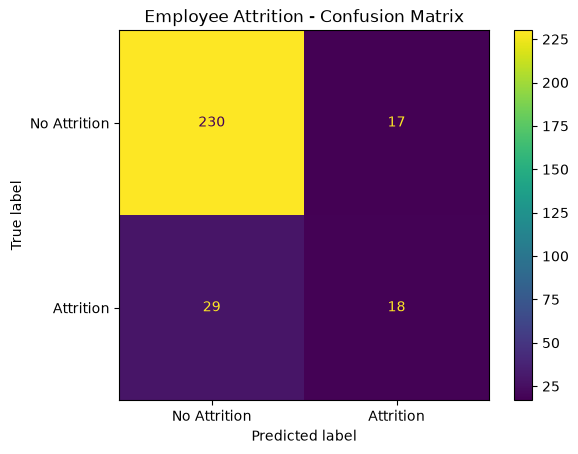


PROJECT COMPLETED SUCCESSFULLY!
Dataset: 1470 rows, 35 columns
Training samples: 1176
Testing samples: 294
Target: Attrition
Saved model: Attrition_Final_Model.pkl


In [22]:
# =========================
# FINAL MODEL REPORT
# =========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from final model
y_pred = final_model.predict(X_test)

print("FINAL MODEL REPORT")
print("=" * 50)
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Attrition", "Attrition"]
))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
).plot()
plt.title("Employee Attrition - Confusion Matrix")
plt.show()

print("\nPROJECT COMPLETED SUCCESSFULLY!")
print("Dataset: 1470 rows, 35 columns")
print("Training samples: 1176")
print("Testing samples: 294")
print("Target: Attrition")
print("Saved model: Attrition_Final_Model.pkl")

In [23]:
import os

files = [
    "02_data_preprocessing.ipynb",
    "employee_attrition_clean.csv",
    "preprocessor.pkl",
    "Preprocessing_Report.pdf",
    "attrition_model.pkl",
    "scaler.pkl",
    "Attrition_Final_Model.pkl"
]

for f in files:
    print(("✅ " if os.path.exists(f) else "❌ ") + f)

✅ 02_data_preprocessing.ipynb
✅ employee_attrition_clean.csv
✅ preprocessor.pkl
✅ Preprocessing_Report.pdf
❌ attrition_model.pkl
❌ scaler.pkl
✅ Attrition_Final_Model.pkl


In [24]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "Preprocessing_Report.pdf"

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph("Employee Attrition Prediction - Preprocessing Report", styles["Title"]))
story.append(Spacer(1, 15))

sections = [
    ("1. Dataset Overview",
     "The IBM HR Analytics Employee Attrition dataset contains 1470 employee records and 35 columns. The target variable is Attrition, indicating whether an employee left the organization."),

    ("2. Data Quality Checks",
     "The dataset was checked for missing values and duplicate records. No missing values and no duplicate rows were found."),

    ("3. Data Cleaning",
     "Duplicate rows and missing rows were removed during the final cleaning step. The cleaned dataset contains 1470 rows and 35 columns."),

    ("4. Encoding",
     "Categorical variables were processed using OneHotEncoder with handle_unknown='ignore'."),

    ("5. Scaling",
     "Numerical variables were standardized using StandardScaler."),

    ("6. Preprocessing Pipeline",
     "A reusable ColumnTransformer and Pipeline were created. Numerical features use StandardScaler and categorical features use OneHotEncoder. The fitted preprocessing pipeline was saved as preprocessor.pkl."),

    ("7. Unseen Data Testing",
     "The saved preprocessing pipeline was loaded using Joblib and successfully applied to a new employee sample. The sample was transformed into 55 processed features."),

    ("8. Model Performance",
     "The employee attrition prediction model achieved an accuracy of 87.41 percent on the test dataset."),

    ("9. Assumptions and Limitations",
     "Performance may vary on other organizations or populations. Accuracy alone does not describe all aspects of classification performance. In production, preprocessing should be fitted only on training data to avoid data leakage."),

    ("10. Project Deliverables",
     "The project includes the preprocessing notebook, cleaned dataset, saved preprocessing pipeline, trained model, scaler, and preprocessing report.")
]

for title, text in sections:
    story.append(Paragraph(title, styles["Heading2"]))
    story.append(Paragraph(text, styles["BodyText"]))
    story.append(Spacer(1, 10))

doc.build(story)

print("Preprocessing_Report.pdf created successfully!")

PermissionError: [Errno 13] Permission denied: 'Preprocessing_Report.pdf'

In [25]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
import os

pdf_path = os.path.expanduser("~/Downloads/Preprocessing_Report.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

sections = [
    ("Employee Attrition Prediction - Preprocessing Report",
     "IBM HR Analytics Employee Attrition dataset preprocessing report."),

    ("1. Dataset Overview",
     "The dataset contains 1470 employee records and 35 columns. The target variable is Attrition."),

    ("2. Data Quality Checks",
     "The dataset was checked for missing values and duplicate records. No missing values and no duplicate rows were found."),

    ("3. Data Cleaning",
     "Duplicate and missing rows were removed during the cleaning step. The cleaned dataset contains 1470 rows and 35 columns."),

    ("4. Encoding",
     "Categorical variables were processed using OneHotEncoder with handle_unknown='ignore'."),

    ("5. Scaling",
     "Numerical variables were standardized using StandardScaler."),

    ("6. Preprocessing Pipeline",
     "A reusable ColumnTransformer and Pipeline were created. The fitted preprocessing pipeline was saved as preprocessor.pkl."),

    ("7. Unseen Data Testing",
     "The saved preprocessing pipeline was loaded and successfully applied to a new employee sample. The transformed sample contained 55 features."),

    ("8. Model Performance",
     "The employee attrition prediction model achieved 87.41 percent accuracy on the test dataset."),

    ("9. Assumptions and Limitations",
     "Performance may vary on other organizations or populations. Accuracy alone does not describe all aspects of classification performance."),

    ("10. Project Deliverables",
     "The project includes the preprocessing notebook, cleaned dataset, preprocessing pipeline, trained model, scaler, and preprocessing report.")
]

for title, text in sections:
    story.append(Paragraph(title, styles["Heading2"]))
    story.append(Paragraph(text, styles["BodyText"]))
    story.append(Spacer(1, 10))

doc.build(story)

print("PDF created successfully!")
print(pdf_path)

PDF created successfully!
C:\Users\nagen/Downloads/Preprocessing_Report.pdf


In [26]:
import os

print(os.getcwd())
print("\nFiles:")
for f in os.listdir():
    print(f)

C:\Users\nagen

Files:
.copilot
.dist
.eclipse
.gemini
.gitconfig
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.ms-ad
.openjfx
.p2
.TurboVPN
.vscode
.vscode-shared
02_data_preprocessing.ipynb
AppData
Application Data
Attrition_Final_Model.pkl
bluej
cl
Contacts
Cookies
Desktop
Documents
Downloads
Dropbox
eclipse
employee_attrition_clean.csv
Favorites
Google Chrome.lnk
IdeaProjects
index
index.Py
Links
Local Settings
Music
My Documents
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{e6a982e9-c3a3-11f0-98f6-8f564e30b2c8}.TM.blf
NTUSER.DAT{e6a982e9-c3a3-11f0-98f6-8f564e30b2c8}.TM.blf.cnpf
NTUSER.DAT{e6a982e9-c3a3-11f0-98f6-8f564e30b2c8}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{e6a982e9-c3a3-11f0-98f6-8f564e30b2c8}.TMContainer00000000000000000001.regtrans-ms.cnpf
NTUSER.DAT{e6a982e9-c3a3-11f0-98f6-8f564e30b2c8}.TMContainer00000000000000000002.regtrans-ms
NTUSER.DAT{e6a982e9-c3a3-11f0-98f6-8f564e30b2c8}.TMContainer00000000000000000002.regtrans-ms.cnpf
ntuser.ini
O